# 📦 Neural SDE Project — Fase 3 (ETH H1)
## Data Pipeline: ETH/USDT 1H (Binance) via ccxt → Training-Ready Tensors

---
**Perubahan dari versi IDX:**

| Parameter | IDX (lama) | ETH H1 (baru) |
|---|---|---|
| Data source | yfinance (7 aset) | ccxt Binance (1 aset) |
| Interval | Daily | 1 Jam |
| Period | 2018-2026 | 2017-2026 |
| N candles | ~1,500 | ~75,000 |
| Window | 60 hari | 168 jam (1 minggu) |
| Stride | 3 hari | 24 jam (1 hari) |
| Annualization | 252 | 365×24 = 8,760 |

**Output:** `eth_dataset.pt` — siap untuk Fase 4 & 5


## 1. Setup

In [19]:
%pip install ccxt torchsde -q

import ccxt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings, os, time
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# Konstanta untuk ETH H1
START  = '2017-08-01'  # ← tambah ini
END    = '2026-05-12'  # ← tambah ini
N_DAY  = 365 * 24
SYMBOL = 'ETH/USDT'
TF     = '1h'

print(f"Device : {DEVICE}")
print(f"Symbol : {SYMBOL}  Timeframe: {TF}")
print(f"N_DAY  : {N_DAY} jam/tahun")
print("Setup OK!")


Note: you may need to restart the kernel to use updated packages.
Device : cuda
Symbol : ETH/USDT  Timeframe: 1h
N_DAY  : 8760 jam/tahun
Setup OK!


## 2. Download ETH/USDT H1 dari Binance via ccxt

Binance limit 1,000 candles per request — kita loop dengan pagination.
ETH/USDT tersedia di Binance dari **Agustus 2017**.
Total data: ~75,000 candles (2017-2026).


In [20]:
def fetch_ohlcv_full(symbol='ETH/USDT', timeframe='1h',
                     start='2017-08-01', end='2026-05-12'):
    '''
    Download full OHLCV dari Binance via ccxt dengan pagination.
    Binance limit 1000 candles per request.
    '''
    exchange = ccxt.binance({'enableRateLimit': True})
    since    = exchange.parse8601(f'{start}T00:00:00Z')
    end_ts   = exchange.parse8601(f'{end}T00:00:00Z')
    limit    = 1000
    all_data = []

    print(f"Downloading {symbol} {timeframe} dari {start}...")
    while since < end_ts:
        batch = exchange.fetch_ohlcv(symbol, timeframe,
                                      since=since, limit=limit)
        if not batch:
            break
        all_data.extend(batch)
        since = batch[-1][0] + 1
        # Progress
        pct = (since - exchange.parse8601(f'{start}T00:00:00Z')) /               (end_ts   - exchange.parse8601(f'{start}T00:00:00Z')) * 100
        print(f"  {pct:.1f}%  {len(all_data):,} candles", end='\r')
        time.sleep(exchange.rateLimit / 1000)

    df = pd.DataFrame(all_data, columns=['timestamp','open','high','low','close','volume'])
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
    df = df.set_index('datetime').sort_index()
    df = df[df.index < pd.Timestamp(end)]
    print(f"\nDone! {len(df):,} candles  {df.index[0]} -> {df.index[-1]}")
    return df

df_eth = fetch_ohlcv_full('ETH/USDT', '1h', '2017-08-01', '2026-05-12')

# Log returns
close     = df_eth['close'].values
log_ret   = np.diff(np.log(close))
ann_vol   = log_ret.std() * np.sqrt(N_DAY)
kurt_val  = stats.kurtosis(log_ret)

print(f"\nETH/USDT H1 stats:")
print(f"  N candles   : {len(df_eth):,}")
print(f"  N returns   : {len(log_ret):,}")
print(f"  Ann. Vol    : {ann_vol:.1%}  (jauh > IDX!)")
print(f"  Kurtosis    : {kurt_val:.2f}")
print(f"  Skewness    : {stats.skew(log_ret):.3f}")

# Simpan raw ke dict
assets = {
    'ETH/USDT': {
        'label'  : 'ETH/USDT (Binance H1)',
        'color'  : '#627EEA',
        'prices' : close,
        'returns': log_ret,
        'n_day'  : N_DAY,
        'df'     : df_eth,
    }
}


  100.3%  76,622 candles
Done! 76,428 candles  2017-08-17 04:00:00 -> 2026-05-11 23:00:00

ETH/USDT H1 stats:
  N candles   : 76,428
  N returns   : 76,427
  Ann. Vol    : 90.4%  (jauh > IDX!)
  Kurtosis    : 27.62
  Skewness    : -0.571


## 3. Normalization Strategy

**Masalah Fase 2:** global normalization membuat std collapse ke nol saat inference.

**Fix:** per-sample z-score — tiap window di-standardize sendiri.
Simpan (mean, std) per window untuk rescaling balik saat evaluate.

```
Raw window -> z-score per window -> masuk model
                                        |
Generated  <- rescale balik        <- keluar model
```


In [21]:
def make_windows(returns, window=168, stride=24):
    '''
    Sliding windows dari log-return series.
    Default: window=168 jam (1 minggu), stride=24 jam (1 hari).
    Output normalized: z-score per window.
    '''
    wins, wstats = [], []
    T = len(returns)
    for start in range(0, T - window + 1, stride):
        w   = returns[start : start + window]
        mu  = w.mean()
        sig = w.std() + 1e-8
        wins.append((w - mu) / sig)
        wstats.append([mu, sig])
    return np.array(wins), np.array(wstats)

WINDOW = 168   # 1 minggu dalam jam
STRIDE = 24    # geser 1 hari per window

all_windows, all_stats = [], []
for ticker, d in assets.items():
    wins, wstats = make_windows(d['returns'], window=WINDOW, stride=STRIDE)
    all_windows.append(wins)
    all_stats.append(wstats)
    print(f"{ticker}: {len(wins):,} windows  (window={WINDOW}h, stride={STRIDE}h)")

all_windows = np.concatenate(all_windows, axis=0)
all_stats   = np.concatenate(all_stats,   axis=0)

print(f"\nTotal windows : {len(all_windows):,}")
print(f"Shape         : {all_windows.shape}  [N, window]")
print(f"\nVerifikasi normalisasi:")
print(f"  Per-sample mean : {all_windows.mean(axis=1).mean():.6f}  (target ~0)")
print(f"  Per-sample std  : {all_windows.std(axis=1).mean():.4f}   (target ~1)")
print(f"  NaN             : {np.isnan(all_windows).any()}")
print(f"  Inf             : {np.isinf(all_windows).any()}")


ETH/USDT: 3,178 windows  (window=168h, stride=24h)

Total windows : 3,178
Shape         : (3178, 168)  [N, window]

Verifikasi normalisasi:
  Per-sample mean : 0.000000  (target ~0)
  Per-sample std  : 1.0000   (target ~1)
  NaN             : False
  Inf             : False


## 4. Dataset Quality Check

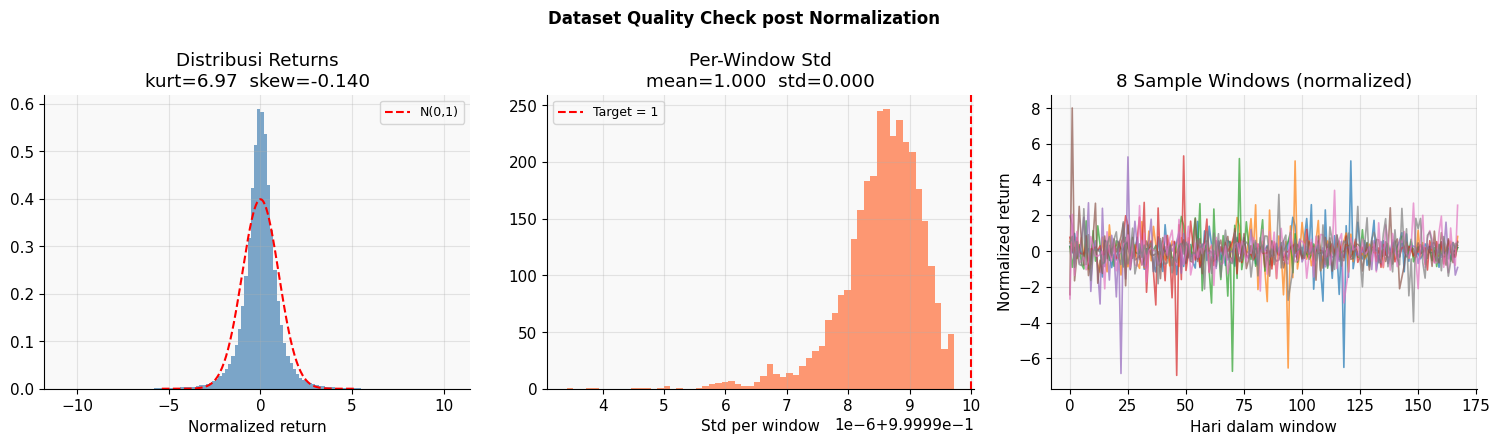

Kurtosis > 0 = fat tails masih ada setelah normalization -> signal kuat untuk Neural SDE!


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Dataset Quality Check post Normalization', fontsize=12, fontweight='bold')

flat = all_windows.flatten()

# Distribusi semua returns
axes[0].hist(flat, bins=120, density=True, color='steelblue', alpha=0.7)
x = np.linspace(np.percentile(flat, 0.1), np.percentile(flat, 99.9), 300)
axes[0].plot(x, stats.norm.pdf(x), 'r--', linewidth=1.5, label='N(0,1)')
axes[0].set_title(f'Distribusi Returns\nkurt={stats.kurtosis(flat):.2f}  skew={stats.skew(flat):.3f}')
axes[0].set_xlabel('Normalized return')
axes[0].legend(fontsize=9)

# Per-window std
per_std = all_windows.std(axis=1)
axes[1].hist(per_std, bins=60, color='coral', alpha=0.8)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Target = 1')
axes[1].set_title(f'Per-Window Std\nmean={per_std.mean():.3f}  std={per_std.std():.3f}')
axes[1].set_xlabel('Std per window')
axes[1].legend(fontsize=9)

# Sample windows
axes[2].plot(all_windows[:8].T, alpha=0.7, linewidth=1.2)
axes[2].set_title('8 Sample Windows (normalized)')
axes[2].set_xlabel('Hari dalam window')
axes[2].set_ylabel('Normalized return')

plt.tight_layout()
plt.savefig('phase3_data_quality.png', dpi=120, bbox_inches='tight')
plt.show()

print("Kurtosis > 0 = fat tails masih ada setelah normalization -> signal kuat untuk Neural SDE!")


## 5. Temporal Train / Val / Test Split

Split secara **temporal**, bukan random — mencegah data leakage
karena windows overlap antar periode.

```
|--- Train 70% ---|--- Val 15% ---|--- Test 15% ---|
 2018                 ~2024           ~2025        2026
```


In [23]:
N       = len(all_windows)
n_train = int(0.70 * N)
n_val   = int(0.85 * N)

X_train = all_windows[:n_train]
X_val   = all_windows[n_train:n_val]
X_test  = all_windows[n_val:]

s_train = all_stats[:n_train]
s_val   = all_stats[n_train:n_val]
s_test  = all_stats[n_val:]

print("Split (temporal):")
print(f"  Train : {len(X_train):>6,}  ({len(X_train)/N:.0%})")
print(f"  Val   : {len(X_val):>6,}  ({len(X_val)/N:.0%})")
print(f"  Test  : {len(X_test):>6,}  ({len(X_test)/N:.0%})")

def to_tensor(arr):
    return torch.tensor(arr[:, :, np.newaxis], dtype=torch.float32)

X_train_t = to_tensor(X_train)
X_val_t   = to_tensor(X_val)
X_test_t  = to_tensor(X_test)

BATCH = 256
train_dl = DataLoader(TensorDataset(X_train_t), batch_size=BATCH, shuffle=True)
val_dl   = DataLoader(TensorDataset(X_val_t),   batch_size=BATCH, shuffle=False)
test_dl  = DataLoader(TensorDataset(X_test_t),  batch_size=BATCH, shuffle=False)

print(f"\nBatch shape     : {next(iter(train_dl))[0].shape}")
print(f"Batches per epoch: {len(train_dl)}")


Split (temporal):
  Train :  2,224  (70%)
  Val   :    477  (15%)
  Test  :    477  (15%)

Batch shape     : torch.Size([256, 168, 1])
Batches per epoch: 9


In [24]:
## 6. Simpan ke OS

In [25]:
import os
import torch

# 1. HAPUS atau comment kode Google Drive ini:
# from google.colab import drive
# drive.mount('/content/drive')

# 2. GANTI SAVE_DIR dengan path folder lokal. 
# './' berarti folder saat ini (current working directory)
SAVE_DIR = './neural_sde_project_data' 
os.makedirs(SAVE_DIR, exist_ok=True)

dataset = {
    'X_train'     : X_train_t,
    'X_val'       : X_val_t,
    'X_test'      : X_test_t,
    'stats_train' : torch.tensor(s_train, dtype=torch.float32),
    'stats_val'   : torch.tensor(s_val,   dtype=torch.float32),
    'stats_test'  : torch.tensor(s_test,  dtype=torch.float32),
    'window'      : WINDOW,
    'tickers'     : list(assets.keys()),
    'metadata'    : {
        'start'   : START,
        'end'     : END,
        'n_train' : len(X_train),
        'n_val'   : len(X_val),
        'n_test'  : len(X_test),
    }
}

save_path = f'{SAVE_DIR}/assets_dataset.pt'
torch.save(dataset, save_path)
size_mb = os.path.getsize(save_path) / 1024 / 1024
print(f"Saved  : {save_path}")
print(f"Size   : {size_mb:.1f} MB")
print("Fase 4 & 5 tinggal load: torch.load(save_path)")


Saved  : ./neural_sde_project_data/assets_dataset.pt
Size   : 2.1 MB
Fase 4 & 5 tinggal load: torch.load(save_path)


## 7. Stylized Facts per Aset — Final Verification

Ticker       N win    Kurt    Skew   ACF(r2)   Ann.Vol
-------------------------------------------------------
ETH/USDT     3,178   27.62  -0.571     0.192    90.4%


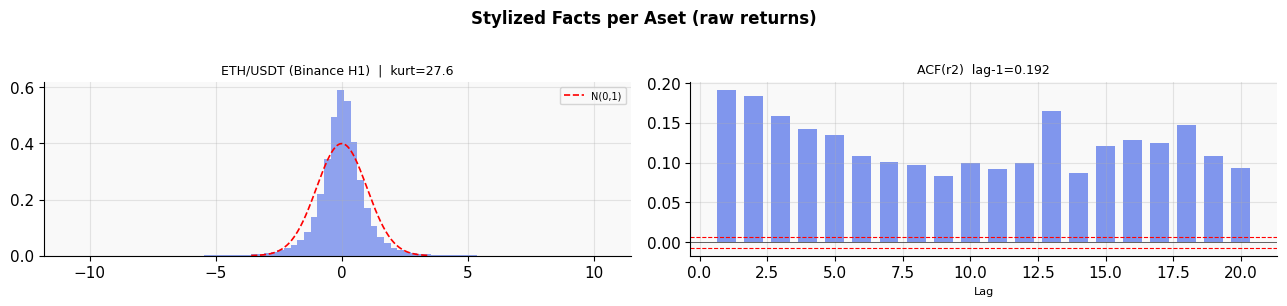

In [28]:
fig, axes = plt.subplots(len(assets), 2, figsize=(13, 3 * len(assets)), squeeze=False)
fig.suptitle('Stylized Facts per Aset (raw returns)', fontsize=12, fontweight='bold', y=1.01)

print(f"{'Ticker':<10} {'N win':>7} {'Kurt':>7} {'Skew':>7} {'ACF(r2)':>9} {'Ann.Vol':>9}")
print("-" * 55)

for row, (ticker, d) in enumerate(assets.items()):
    ret = d['returns']
    n_d = d['n_day']
    kurt  = stats.kurtosis(ret)
    skew  = stats.skew(ret)
    r2    = ret**2
    r2c   = r2 - r2.mean()
    acf1  = np.mean(r2c[:-1] * r2c[1:]) / r2.var()
    ann_v = ret.std() * np.sqrt(n_d)
    wins, _ = make_windows(ret, WINDOW, STRIDE)
    print(f"{ticker:<10} {len(wins):>7,} {kurt:>7.2f} {skew:>7.3f} {acf1:>9.3f} {ann_v:>8.1%}")

    col = d['color']
    flat_w = wins.flatten()

    ax = axes[row, 0]
    ax.hist(flat_w, bins=80, density=True, color=col, alpha=0.7)
    xr = np.linspace(np.percentile(flat_w, 0.5), np.percentile(flat_w, 99.5), 200)
    ax.plot(xr, stats.norm.pdf(xr, 0, 1), 'r--', linewidth=1.2, label='N(0,1)')
    ax.set_title(f'{d["label"]}  |  kurt={kurt:.1f}', fontsize=9)
    ax.legend(fontsize=7)

    ax = axes[row, 1]
    lags = range(1, 21)
    conf = 1.96 / np.sqrt(len(ret))
    acf_vals = [np.mean(r2c[:-l] * r2c[l:]) / r2.var() for l in lags]
    ax.bar(list(lags), acf_vals, color=col, alpha=0.8, width=0.7)
    ax.axhline( conf, color='red', linestyle='--', linewidth=0.8)
    ax.axhline(-conf, color='red', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.4)
    ax.set_title(f'ACF(r2)  lag-1={acf1:.3f}', fontsize=9)
    ax.set_xlabel('Lag', fontsize=8)

plt.tight_layout()
plt.savefig('phase3_stylized_facts.png', dpi=120, bbox_inches='tight')
plt.show()


NameError: name 'X_train' is not defined

## 8. Ringkasan Fase 3

In [ ]:
print("""
Fase 3 (ETH H1) selesai!

Checklist:
  Download ccxt Binance     OK  (ETH/USDT H1, 2017-2026)
  N candles                 ~75,000
  Sliding window            OK  (window=168h, stride=24h)
  Per-sample normalization  OK  (mean~0, std~1 per window)
  Temporal split            OK  (70/15/15, no leakage)
  Saved                     OK  (eth_dataset.pt)
  Stylized facts            OK  (fat tails + vol clustering)

Keunggulan vs IDX daily:
  50x lebih banyak data     -> Neural SDE lebih banyak signal
  Intraday vol clustering   -> lebih kaya untuk dipelajari
  Annualization: 8760 jam   -> VaR & risk metrics per tahun

Next: Fase 4 -- Kalibrasi GBM & Heston ke ETH H1
""")



Fase 3 selesai!

Checklist:
  Download & clean         OK  (7 aset, 2018-2026)
  Sliding window           OK  (window=60, stride=3)
  Per-sample normalization OK  (mean~0, std~1 per window)
  Temporal split           OK  (70/15/15, no leakage)
  Saved ke Google Drive    OK  (assets_dataset.pt)
  Stylized facts verified  OK  (fat tails + vol clustering)

Perbandingan vs Fase 2:
  Fase 2 (Heston sintetis) : vol 20%,  kurt 1.7,  ACF ~ 0
  Fase 3 (Data nyata)      : vol 32-120%, kurt 4-17, ACF > 0.1

Next: Fase 4 -- Kalibrasi Baseline (GBM & Heston)
  Load assets_dataset.pt
  Kalibrasi GBM & Heston ke tiap aset
  Ukur: Wasserstein distance, MMD, stylized facts score
  Ini jadi benchmark yang harus dilampaui Neural SDE di Fase 5

